# RG1 Gene Expression Model Creation

Previously, we were able to deconvolve the chromatin and gene expression for CLB2 from Yulong's replicate 2 data set. However, we previously discussed that this dataset, because it uses an alpha factor arrest, may need to have a different way to represent the recovery phase of the cell cycle. 

Rather than use the Recovery, CG1, postG1 phases to represent the initial branch. We will switch to the RG1, postG1 phases for these cells. The motivation is that, these cells that are recoverying from alpha factor, are continuing to recover through their own special version of G1 that will be distinct from the Common (Mother) G1 cells and the Daughter G1 cells.

So the tasks will be:
1. We will need to decide if we are using 2 or 3 Wavelets.
    - The original model used two wavelets, one for initial and top combined, and the second for the bottom branch. Let's try this for this model for now, and see how it fits. This will reduce the complexity of needing another factor to balance between a third wavelet.
    - The concern may be that we will be duplicating postG1 multiple times in this first smoothing constraint.
3. Create the model file for RG1. We have one already, but we should update the time points to be a power of two when we combine the initial and top branches, and make sure the bottom branch is a power of two for the wavelet.
4. Then, we should be able to deconvolve and evaluate if this model is a good one for fitting with. Or if there are other parameters we will need to adjust.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Let's port over the model creation file from the cell cycle repository.

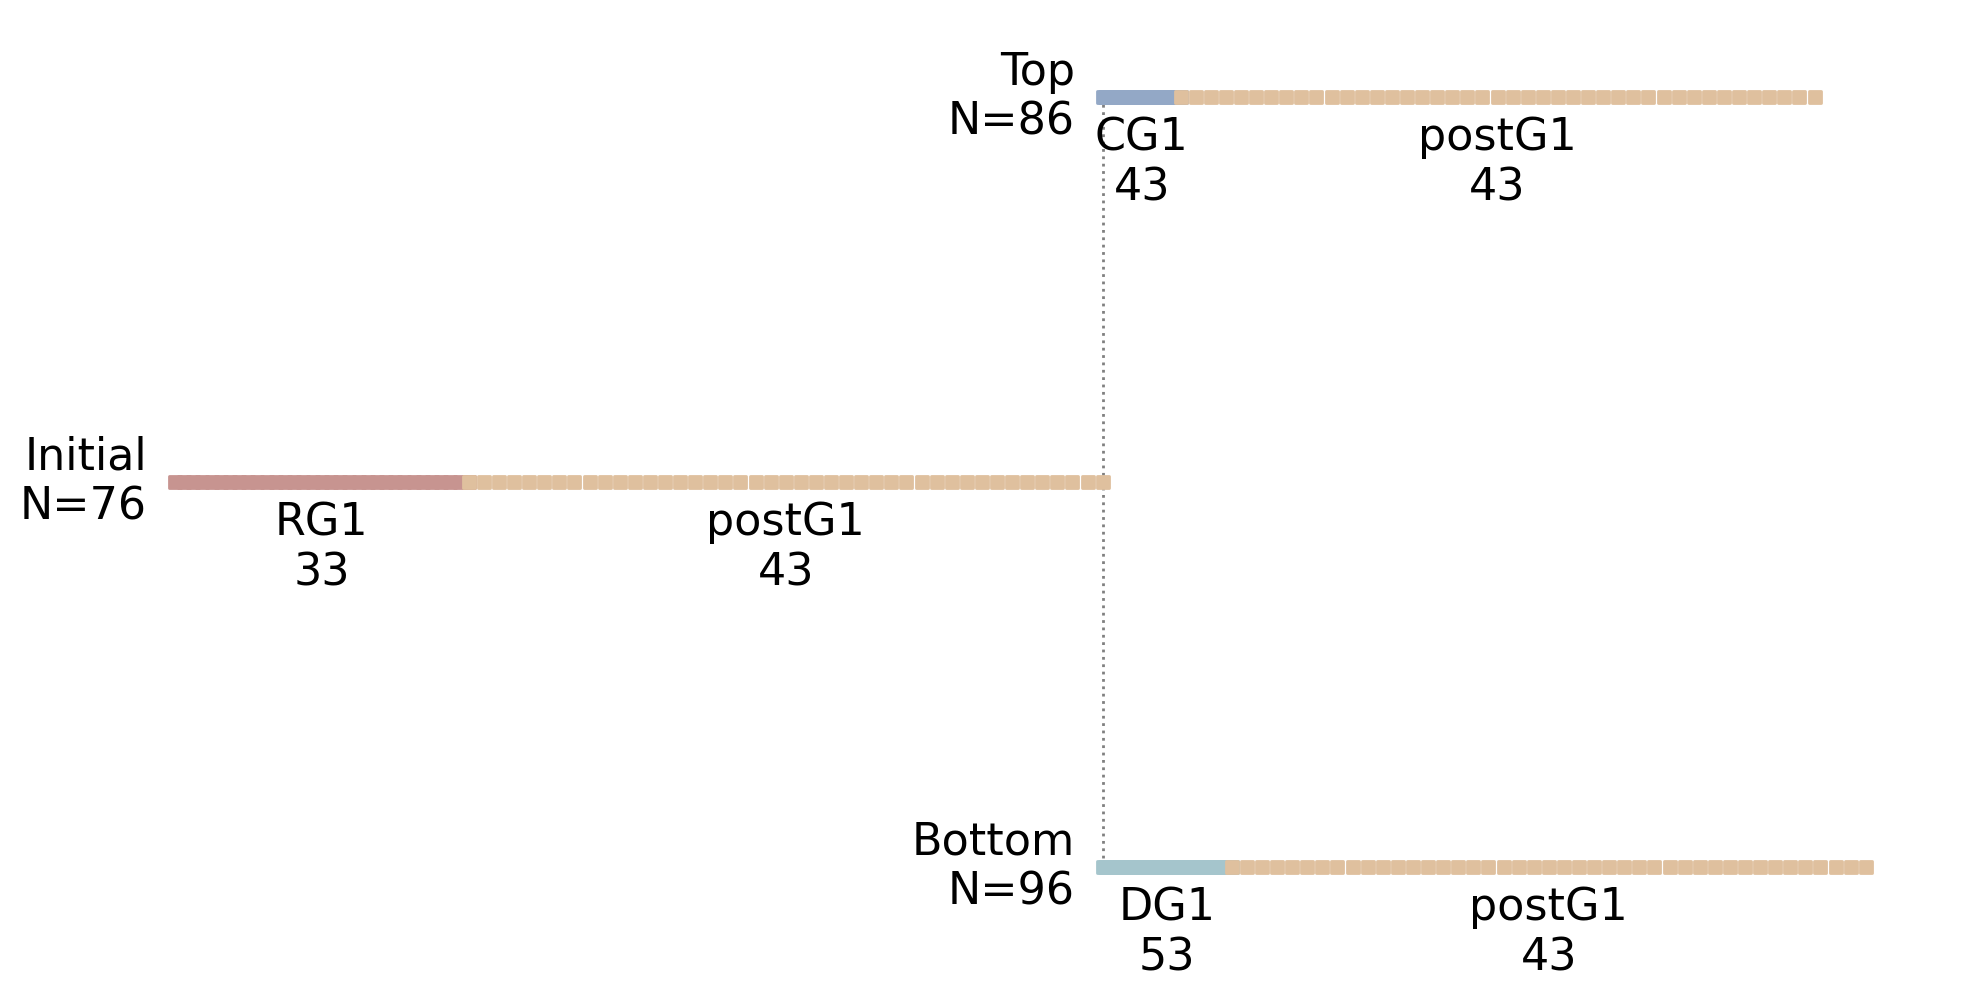

In [15]:
from src.create_models import create_model_rg1_model, get_model_cfg_str

output_model_path = 'models/yl_cell_cycle/wt2_rg1_2023_12_06_update.label'
posteriors_filepath = 'data/cloccs_output_yl_replicate2/posteriors.txt'

wt2_params, rep2_model = create_model_rg1_model(posteriors_filepath)

wt2_cfg = get_model_cfg_str(wt2_params, rep2_model, Rname="RG1", CG1_intervals="t 0", 
        PG1_intervals="i 1 t 1 b 1")

with open(output_model_path, 'w') as f:
    f.write(wt2_cfg)

from src.ModelFile import ModelFile

model_file = ModelFile()
model_file.load_model(output_model_path)
model_file.plot_model()


In [16]:

# Now we would like to verify the lengths of the initial and top branches
# and the bottom branches.
# We would like these to be a power of two for our deconvolution wavelets.


In [17]:
# Let's compare to the original 1.1.1. model

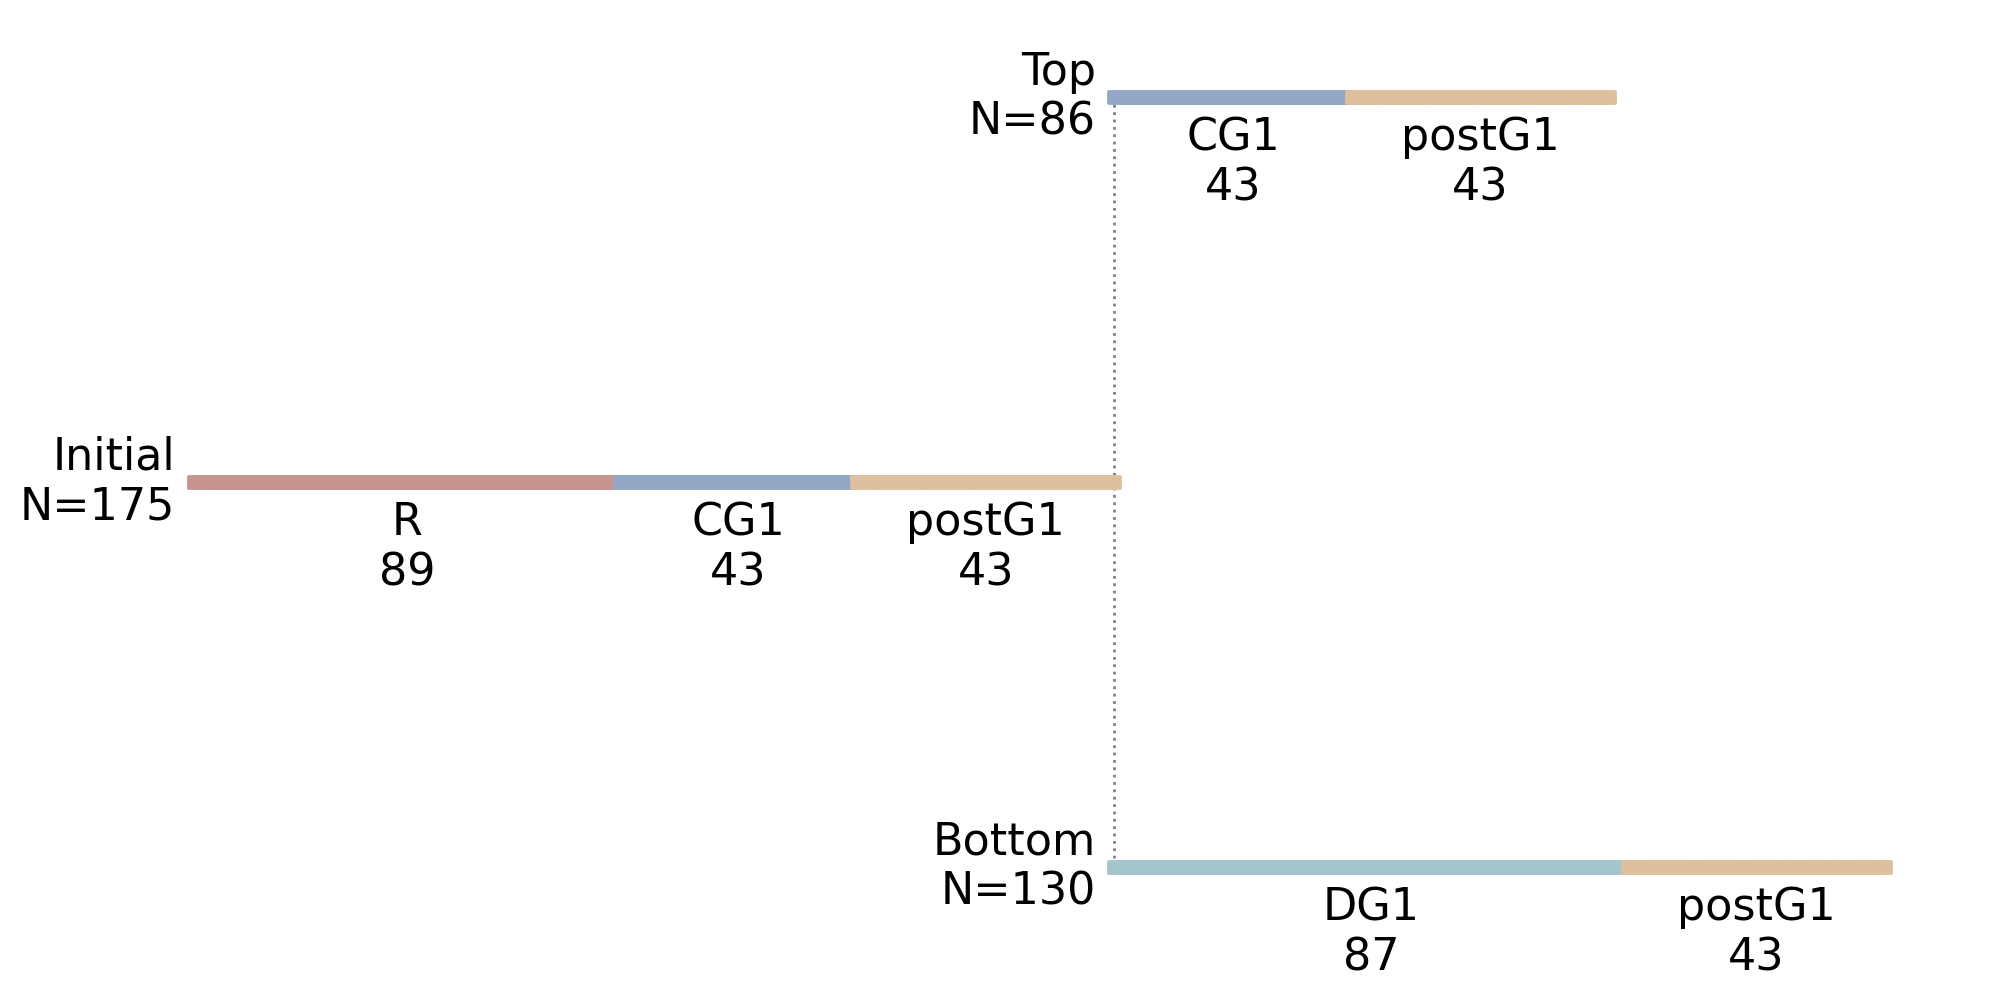

In [19]:
model_file = ModelFile()
model_file.load_model('models/original_budflow/wt1_budflow/1.1.1.26.label')
model_file.plot_model()

# The top and initial combined branches are: 43 + 43 + 89 + 43 + 43 - 5 = 256
# We subtract 5 because each subinterval includes the last index, while we do not
# want that last index in the calculation.

# The bottom branch is: 87 + 43 - 2 = 128

In [25]:
"""
Let's preserve the length of DG1 as 87, that will take care of the bottom branch
as a power of 2

Let's now look at the Initial and top branches
Supposedly, CG1 should be shorter than DG1, if we set CG1 to 43 like in the original model:

Top: 43 + 43
Initial: 33 + 43
We get: 43 + 43 + 33 + 43 - 4 = 158
So, rather we can extend the initial branch recovery to another 100 timepoints or reduce
by 30. I think it may be better to increase CG1 and RG1 both.

Top: 63 + 43
Initial: 53 + 43

May be we should look at the cell cycle parameters:

Recovery time:                                    -23 min
Cell cycle length:                                 77 min
Gamma1*lambda (length CG1)       0.1 * 77 min =    8 min
postG1:                                77 - 8 =   69 min
delta (daughter delay):                            6 min  ** much shorter than XG ***

--------------------------------------------------------

Created by eye with some thoughts in mind:

That postG1 is the longest interval, Delta G1 is a little larger than CG1, 
and RG1 is longer than both CG1 and DG1

RG1      60
CG1      30
DG1      40
postG1   90

--------------------------------------------------------

Next we can make these rounded to powers of two:

RG1      60
CG1      30
DG1      40
postG1   90

DG1 + postG1 = 40 + 90 -2 = 128 (good)
RG1 + postG1 + CG1 + postG1 = 60 + 90 + 30 + 90 -4 = 266 (subtract 10)

--------------------------------------------------------

So let's reduce 5 from RG1 and CG1 each

RG1      55
CG1      25
DG1      40
postG1   90

DG1 + postG1 = 40 + 90 -2 = 128 (good)
RG1 + postG1 + CG1 + postG1 = 55 + 90 + 25 + 90 -4 = 256 (good

"""


9

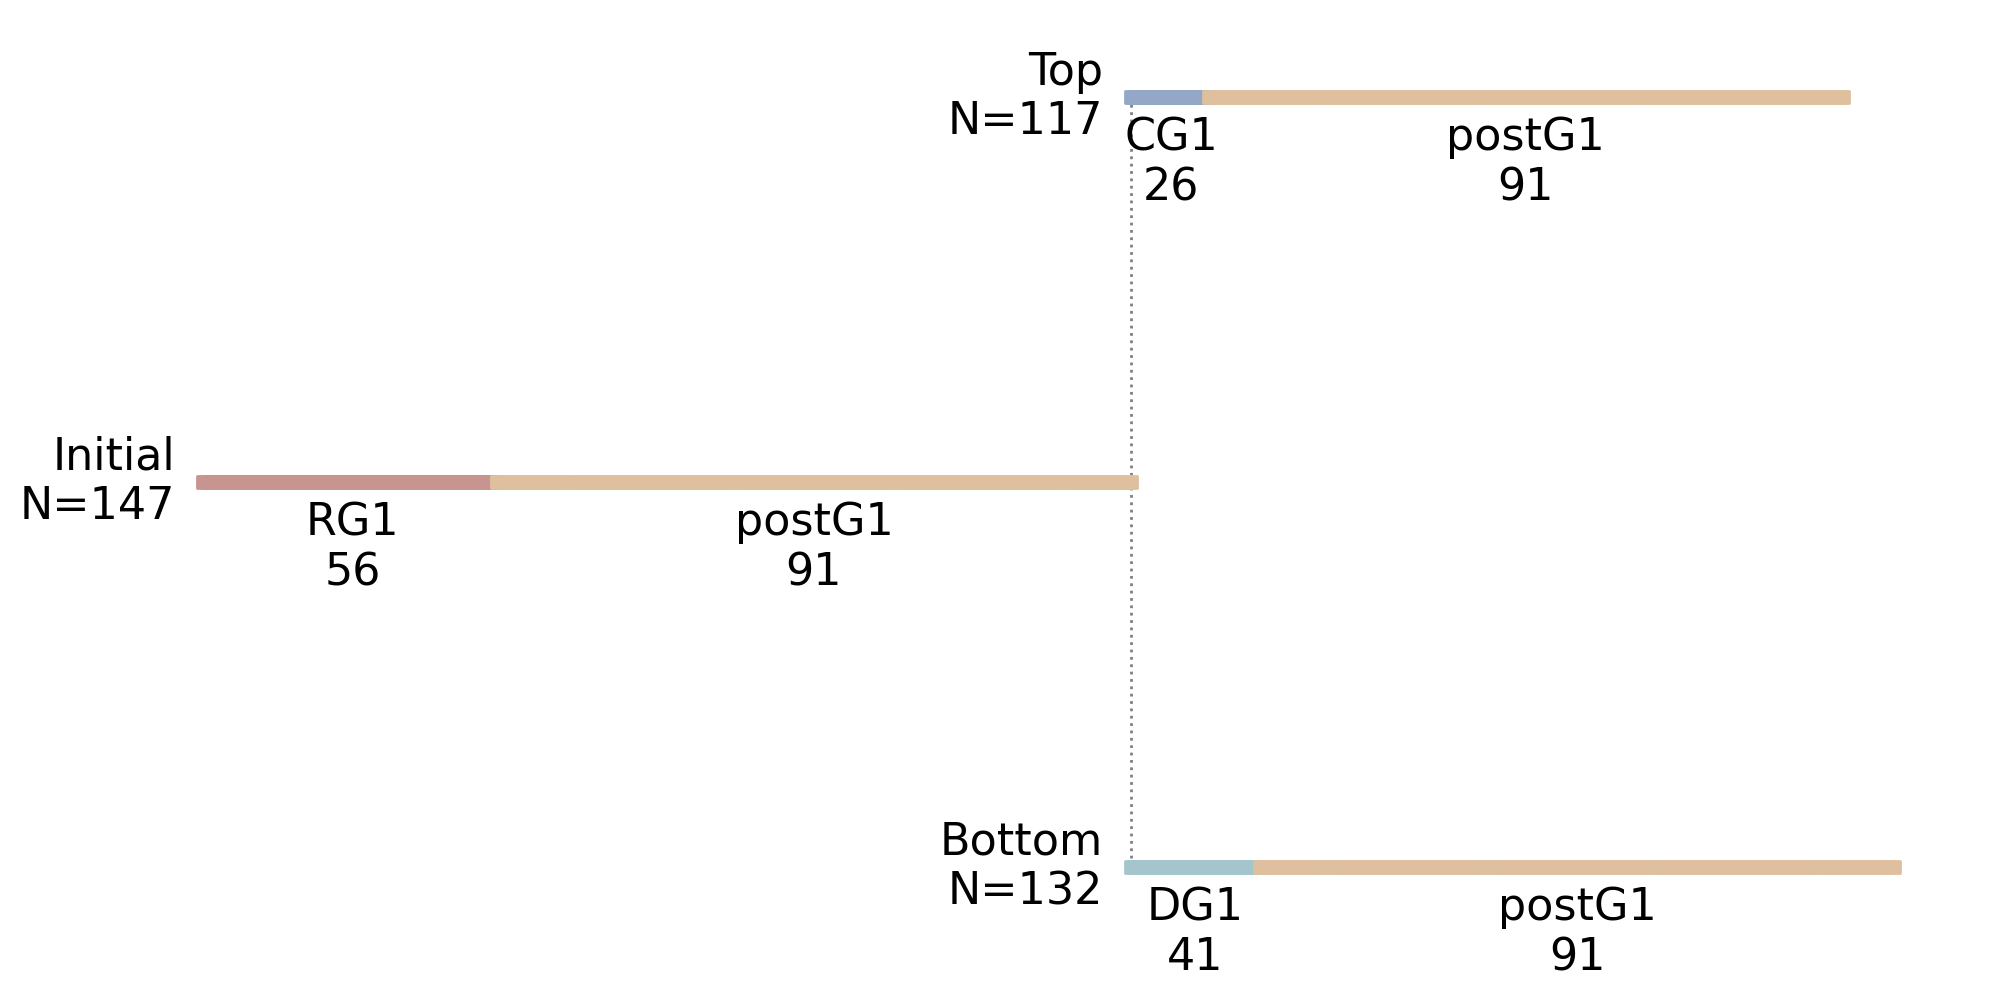

In [27]:
# Updated model with new numbers

from src.create_models import create_model_rg1_model, get_model_cfg_str

output_model_path = 'models/yl_cell_cycle/wt2_rg1_2023_12_06_update.label'
posteriors_filepath = 'data/cloccs_output_yl_replicate2/posteriors.txt'

wt2_params, rep2_model = create_model_rg1_model(posteriors_filepath)

wt2_cfg = get_model_cfg_str(wt2_params, rep2_model, Rname="RG1", CG1_intervals="t 0", 
        PG1_intervals="i 1 t 1 b 1")

with open(output_model_path, 'w') as f:
    f.write(wt2_cfg)

from src.ModelFile import ModelFile

model_file = ModelFile()
model_file.load_model(output_model_path)
model_file.plot_model()


In [30]:
# Now let's see how the H matrix looks

